In [1]:
from sklearn.metrics import mean_absolute_error

from functions import *

import numpy as np
import os
from scipy.signal import butter, filtfilt, find_peaks
from scipy.linalg import logm
from scipy.io import savemat, loadmat
import scipy.io as spio
import pandas as pd
from datetime import datetime
from vedo import Points, Plotter, Line, Grid
from IPython.display import Video
import imageio.v2 as imageio
import shutil
import seaborn as sns
import stumpy

import matplotlib
import matplotlib.pyplot as plt

from mobgap.data import GenericMobilisedDataset
from mobgap.pipeline import MobilisedPipelineImpaired
from mobgap.aggregation import get_mobilised_dmo_thresholds


import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=UserWarning) 

C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please re

In [2]:
def filt(fc, fs, data):
    w = fc / (fs / 2) # Normalize the frequency
    b, a = butter(4, w, 'low')
    output = filtfilt(b, a, data, axis=0)
    return output

In [3]:
def get_start_end_times(imu_data, plot_peaks=True):
    # calculate magnitude of acceleration
    imu_mag = np.sqrt(
        imu_data["Accel-X (g)"]**2 +
        imu_data[" Accel-Y (g)"]**2 +
        imu_data[" Accel-Z (g)"]**2
    )

    # find peaks and their properties
    peaks, properties = find_peaks(imu_mag, height=8, distance=100) # 1ms buffer zone

    # sort peaks by height (largest first)
    heights = properties["peak_heights"]
    
    if plot_peaks:
        print(heights)
        
    sorted_by_height = peaks[np.argsort(heights)[::-1]]  # sort descending by height

    # take top 6 peaks (largest heights)
    top6_peaks = np.sort(sorted_by_height[:6])

    # pick rightmost of the left peaks and leftmost of the right peaks among the top 6
    left_peak = top6_peaks[2]
    right_peak = top6_peaks[3]

    print(f"Top 6 peaks (indices): {np.sort(top6_peaks)}")
    print(f"Selected leftmost: {left_peak}, rightmost: {right_peak}")

    imu_data["Time"] = pd.to_datetime(imu_data["Time"], format="%Y-%m-%d %H:%M:%S.%f")

    if plot_peaks:
        for i, p in enumerate([left_peak, right_peak]):
            start_idx = max(0, p - 5000)
            end_idx = min(len(imu_data) - 1, p + 5000)

            plt.figure(figsize=(10, 4))
            plt.plot(imu_data["Time"].iloc[start_idx:end_idx],
                     imu_mag.iloc[start_idx:end_idx],
                     label=f"Peak {i+1} window")

            plt.axvline(imu_data["Time"].iloc[p], color='red', linestyle='--', label="Peak")

            plt.xlabel("Time")
            plt.ylabel("Acceleration Magnitude")
            plt.title(f"IMU Acceleration Around Peak {i+1}")
            plt.legend()
            plt.tight_layout()
            plt.show()

    trimmed_data = imu_data.iloc[left_peak:right_peak].reset_index(drop=True)
    return trimmed_data

def generate_trimmed_resampled_axivity(raw_data_folder, prints = False):
    axivity_data_folder = raw_data_folder + "Axivity Data\\"
    
    imu_data_1 = pd.read_csv(axivity_data_folder + "wrist.resampled.csv", header=0)
    imu_data_2 = pd.read_csv(axivity_data_folder + "lower_back.resampled.csv", header=0)

    if prints:
        print(f"Finding peaks...")
    imu_data_1 = get_start_end_times(imu_data_1, prints)
    imu_data_2 = get_start_end_times(imu_data_2, prints)

    if prints:
        print()
        print("Raw:")
        print(f"Start time 1: {imu_data_1["Time"].iloc[0]}, Start time 2: {imu_data_2["Time"].iloc[0]}")
        print(f"End time 1: {imu_data_1["Time"].iloc[-1]}, End time 2: {imu_data_2["Time"].iloc[-1]}")
        print()
    
    # pick a 'true' time (doesn't really matter so just adjust imu_data_2)
    start_time_diff = imu_data_1["Time"].iloc[0] - imu_data_2["Time"].iloc[0]
    imu_data_2["Time"] = imu_data_2["Time"] + start_time_diff

    if prints:
        print("Adjusted start time:")
        print(f"Start time 1: {imu_data_1["Time"].iloc[0]}, Start time 2: {imu_data_2["Time"].iloc[0]}")
        print(f"End time 1: {imu_data_1["Time"].iloc[-1]}, End time 2: {imu_data_2["Time"].iloc[-1]}")
        print()
    
    # Calculate durations
    duration_1 = imu_data_1['Time'].iloc[-1] - imu_data_1["Time"].iloc[0]
    duration_2 = imu_data_2['Time'].iloc[-1] - imu_data_2['Time'].iloc[0]  # start_time_2 has already been adjusted
    
    # Calculate scaling factor
    scale_factor = duration_1 / duration_2

    if prints:
        print(f"Scale factor: {scale_factor}")
        print()
    
    # Apply scaling to imu_data_2 times
    imu_data_2["Time"] = imu_data_1["Time"].iloc[0] + (imu_data_2["Time"] - imu_data_1["Time"].iloc[0]) * scale_factor

    if prints:
        # Check result
        print("Fully adjusted:")
        print(f"Start time 1: {imu_data_1["Time"].iloc[0]}, Start time 2: {imu_data_2["Time"].iloc[0]}")
        print(f"End time 1: {imu_data_1["Time"].iloc[-1]}, End time 2: {imu_data_2["Time"].iloc[-1]}")
        
        print()
        print("Original:")
        print(f"length of imu_data_1 = {len(imu_data_1["Time"])}")
        print(f"length of imu_data_2 = {len(imu_data_2["Time"])}")
    
    # Step 1: Make sure time is datetime and sorted
    imu_data_1["Time"] = pd.to_datetime(imu_data_1["Time"])
    imu_data_2["Time"] = pd.to_datetime(imu_data_2["Time"])
    imu_data_1 = imu_data_1.sort_values("Time").reset_index(drop=True)
    imu_data_2 = imu_data_2.sort_values("Time").reset_index(drop=True)
    
    # Step 2: Use merge_asof to align imu_data_2 onto imu_data_1's timestamps
    # This allows near-time matching, not exact
    imu_data_2_interp = pd.merge_asof(
        imu_data_1[["Time"]],     # use imu_data_1 timestamps as the reference
        imu_data_2,               # data to be aligned
        on="Time",
        direction="nearest",      # could also try 'forward' or 'backward'
        tolerance=pd.Timedelta("15ms")  # match only if within this range
    )
    
    # Step 1: Set time as index
    imu_data_2_interp = imu_data_2_interp.set_index("Time")
    
    # Step 2: Interpolate over numeric columns using datetime index
    imu_data_2_interp = imu_data_2_interp.interpolate(method="time", limit_area="inside")
    
    # Step 3: Reset index to bring "Time" back as a column
    imu_data_2_interp = imu_data_2_interp.reset_index()
    
    # Step 4: Fill any edge NaNs (if needed)
    imu_data_2_interp = imu_data_2_interp.bfill().ffill()

    if prints:
        print()
        print("Interpolated:")
        print(f"length of imu_data_1 = {len(imu_data_1)}")
        print(f"length of imu_data_2_interp = {len(imu_data_2_interp)}")

    # Our peaks can cause issues with synchronisation - let's crop them off
    # this can be improved if needed
    imu_data_1 = imu_data_1.iloc[200:-200]
    imu_data_2_interp = imu_data_2_interp.iloc[200:-200]
    
    # now save the data as csv in the axivity folder
    imu_data_1.to_csv(axivity_data_folder+"trimmed_resampled_wrist.csv")
    imu_data_2_interp.to_csv(axivity_data_folder+"trimmed_resampled_lower_back.csv")


In [4]:
def forward_fill_rotations(R_rel_array):
    """Forward-fill NaNs in a sequence of 3x3 rotation matrices."""
    R_filled = R_rel_array.copy()
    N, rows, cols = R_rel_array.shape
    for i in range(rows):
        for j in range(cols):
            series = pd.Series(R_rel_array[:, i, j])
            R_filled[:, i, j] = series.ffill().fillna(0)
    return R_filled

def get_angular_velocity_from_plane(marker_O, marker_X, marker_Y, marker_fs):
    R_mocap = []
    for i in range(len(marker_O)):
        v1 = marker_X[i] - marker_O[i]
        v2 = marker_Y[i] - marker_O[i]

        # Skip if degenerate (collinear or zero length)
        if np.linalg.norm(v1) < 1e-8 or np.linalg.norm(v2) < 1e-8:
            R_mocap.append(np.eye(3))
            continue

        x_hat = v1 / np.linalg.norm(v1)
        z_hat = np.cross(v1, v2)
        if np.linalg.norm(z_hat) < 1e-8:  # collinear case
            R_mocap.append(np.eye(3))
            continue
        z_hat /= np.linalg.norm(z_hat)
        y_hat = np.cross(z_hat, x_hat)

        R = np.column_stack((x_hat, y_hat, z_hat))
        R_mocap.append(R)

    R_mocap = np.array(R_mocap)
    dt = 1 / marker_fs

    # Relative rotations
    R_rel_list = []
    for i in range(len(R_mocap) - 1):
        R_t = R_mocap[i]
        R_next = R_mocap[i + 1]
        R_rel = R_t.T @ R_next
        R_rel_list.append(R_rel)

    R_rel_array = np.array(R_rel_list)

    # (Optional) forward fill missing rotations
    R_rel_filled = forward_fill_rotations(R_rel_array)

    ang_vel = np.zeros((len(R_rel_filled), 3))
    for i, R in enumerate(R_rel_filled):
        # Guard against invalid matrices
        if np.allclose(R, 0) or not np.isfinite(R).all():
            R = np.eye(3)

        try:
            omega_skew = logm(R) / dt
        except Exception:
            omega_skew = np.zeros((3, 3))

        ang_vel[i] = [
            omega_skew[2, 1],
            omega_skew[0, 2],
            omega_skew[1, 0]
        ]

    ang_vel = np.rad2deg(ang_vel)
    aligned_ang_vel = np.copy(ang_vel)

    return aligned_ang_vel, ang_vel

def resample_to_100Hz(df, fs):
    if fs < 100:
        print("Resampling to 100Hz...")
        df = df.set_index("Time")
        # Create a new time index at 100 Hz
        new_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="10ms")  # 10ms = 100Hz
        df = df.reindex(df.index.union(new_index))
        df = df.interpolate(method="linear").reindex(new_index)  # Linear interpolation
        df = df.reset_index().rename(columns={"index": "Time"})
        df_fs = len(df)/(df["Time"].iloc[-1] - df["Time"].iloc[0]).total_seconds()
        return df, df_fs
    return df, fs

def find_start_time_multivariate(short_df, long_df, prints=True):
    Q = np.array(short_df, dtype=np.float64)
    T = np.array(long_df, dtype=np.float64)
    
    n_dims = Q.shape[1]

    if T.shape[1] != n_dims:
        raise ValueError("Dimensions of query and time series do not match!")

    profile_len = len(T) - len(Q) + 1
    combined_distance_sq = np.zeros(profile_len)

    for i in range(n_dims):
        dist_profile_1d = stumpy.mass(Q[:, i], T[:, i])
        combined_distance_sq += dist_profile_1d ** 2 # will be used for euclidean distance later
        
    return combined_distance_sq

def align_imu_mocap(raw_data_folder, prints = False):
    # must be wrist data
    imu_data = pd.read_csv(raw_data_folder + r"Axivity Data\trimmed_resampled_wrist.csv", header=0)
    imu_data["Time"] = pd.to_datetime(imu_data["Time"], format="%Y-%m-%d %H:%M:%S.%f")
    imu_data = imu_data.drop(imu_data.columns[imu_data.columns.str.contains('unnamed', case=False)], axis=1)
    imu_fs = float(round(len(imu_data)/(imu_data["Time"].iloc[-1] - imu_data["Time"].iloc[0]).total_seconds()))

    imu_waist = pd.read_csv(raw_data_folder + r"Axivity Data\trimmed_resampled_lower_back.csv", header=0)
    imu_waist["Time"] = pd.to_datetime(imu_waist["Time"], format="%Y-%m-%d %H:%M:%S.%f")
    imu_waist = imu_waist.drop(imu_waist.columns[imu_waist.columns.str.contains('unnamed', case=False)], axis=1)
    imu_waist_fs = float(round(len(imu_waist)/(imu_waist["Time"].iloc[-1] - imu_waist["Time"].iloc[0]).total_seconds()))

    if prints:
        print(f"Source imu_wrist_fs: {imu_fs}")
        print(f"Source imu_waist_fs: {imu_waist_fs}")
    
    # Apply resampling if needed
    imu_data, imu_fs = resample_to_100Hz(imu_data, imu_fs)
    imu_waist, imu_waist_fs = resample_to_100Hz(imu_waist, imu_waist_fs)

    if prints:
        print(f"Interpolated imu_wrist_fs: {imu_fs}")
        print(f"Interpolated imu_waist_fs: {imu_waist_fs}")
    
    # init data structure
    data = {
        "TimeMeasure1": {
        }
    }
    
    # get all the marker data file names in order to make sure they maintain this order
    file_names = [
        "standing.tsv",
        "10m_walk.tsv",
        "10m_walk_bag.tsv",
        "10m_walk_utensils.tsv",
        "10m_walk_step.tsv",
        "tug.tsv",
        "TCW.tsv",
        "TCCW.tsv",
        "dumbbell.tsv",
    ]
    
    tsv_files = [
        os.path.join(raw_data_folder, "Motion Capture Data", f) if os.path.exists(os.path.join(raw_data_folder, "Motion Capture Data", f)) else None
        for f in file_names
    ]

    for test_no, file_name in enumerate(tsv_files):
        if not file_name == None:
            # get marker data
            marker_data = pd.read_table(file_name, sep = '\t', skiprows = range(0, 11))
    
            # clean up the extra columns/markers that can be present - these will always be called "unnamed"
            marker_data = marker_data.drop(marker_data.columns[marker_data.columns.str.contains('unnamed', case=False)], axis=1)

            # perform interpolation on the marker data where all columns are 0 to prevent massive spikes in angular velocity
            marker_cols = marker_data.columns.difference(["Frame", "Time"])
            marker_data[marker_cols] = marker_data[marker_cols].replace(0, np.nan)
            marker_data[marker_cols] = marker_data[marker_cols].interpolate(axis=0).ffill().bfill()
            
            marker_start_time = pd.read_table(file_name, skiprows = [*range(0, 7), 8], header=None, on_bad_lines = 'skip').to_numpy()
    
            if prints:
                print(f"Number of NaNs = {marker_data.isna().sum().sum()}")
                print(f"Marker start time: {marker_start_time}")
            
            # convert string start time to datetime
            marker_start_time = datetime.strptime(marker_start_time[:, 1][0], '%Y-%m-%d, %H:%M:%S.%f').timestamp()
            
            wrist_base = marker_data[["WRIST X", "WRIST Y", "WRIST Z"]].values
            wrist_med = marker_data[["WRIST_MED X", "WRIST_MED Y", "WRIST_MED Z"]].values
            wrist_lat = marker_data[["WRIST_LAT X", "WRIST_LAT Y", "WRIST_LAT Z"]].values
    
            back_base = marker_data[["BACK_O X", "BACK_O Y", "BACK_O Z"]].values
            back_x = marker_data[["BACK_X X", "BACK_X Y", "BACK_X Z"]].values
            back_y = marker_data[["BACK_Y X", "BACK_Y Y", "BACK_Y Z"]].values
            
            marker_data["Time"] = marker_data["Time"].values + marker_start_time
            marker_data["Time"] = pd.to_datetime(marker_data["Time"], unit='s')
    
            marker_fs = float(round(len(marker_data)/(marker_data["Time"].iloc[-1] - marker_data["Time"].iloc[0]).total_seconds()))
            
            if prints:
                print(f"marker_fs: {marker_fs}")
    
            marker_reformatted_time = marker_data["Time"].astype('int64') // 10**9  # convert nanoseconds to seconds       
            marker_reformatted_time = marker_reformatted_time.values.reshape(-1, 1)
    
            # get the angular velocity of the plane defined by the wrist (then back), and switch the axes to match the IMU (done experimentally)
            aligned_ang_vel, ang_vel = get_angular_velocity_from_plane(wrist_base, wrist_med, wrist_lat, marker_fs)
            aligned_ang_vel[:, 0] = -ang_vel[:, 1]
            aligned_ang_vel[:, 1] = -ang_vel[:, 0]
            aligned_ang_vel[:, 2] = -ang_vel[:, 2]
            
            aligned_ang_vel_waist, ang_vel_waist = get_angular_velocity_from_plane(back_base, back_x, back_y, marker_fs)
            aligned_ang_vel_waist[:, 0] = ang_vel_waist[:, 1]
            aligned_ang_vel_waist[:, 1] = ang_vel_waist[:, 0]
            aligned_ang_vel_waist[:, 2] = -ang_vel_waist[:, 2]
            
            # get imu data
            imu_ang = imu_data[[' Gyro-X (d/s)', ' Gyro-Y (d/s)', ' Gyro-Z (d/s)']].to_numpy()
            imu_waist_ang = imu_waist[[' Gyro-X (d/s)', ' Gyro-Y (d/s)', ' Gyro-Z (d/s)']].to_numpy()
            imu_time = imu_data['Time'].to_numpy()
            imu_waist_time = imu_waist['Time'].to_numpy()
            
            # calculate magnitudes
            imu_mag = np.linalg.norm(imu_ang, axis=1)
            imu_waist_mag = np.linalg.norm(imu_waist_ang, axis=1)
            mocap_mag = np.linalg.norm(aligned_ang_vel, axis=1)
            mocap_waist_mag = np.linalg.norm(aligned_ang_vel_waist, axis=1)
    
            cutoff_frequency = 10
            
            # filter relavent axes
            aligned_ang_vel = filt(cutoff_frequency, marker_fs, aligned_ang_vel)
            aligned_ang_vel_waist = filt(cutoff_frequency, marker_fs, aligned_ang_vel_waist)
            imu_ang = filt(cutoff_frequency, imu_fs, imu_ang)
            imu_waist_ang = filt(cutoff_frequency, imu_waist_fs, imu_waist_ang)

            # get square distances
            dist_sq_wrist = find_start_time_multivariate(aligned_ang_vel, imu_ang, prints)
            dist_sq_waist = find_start_time_multivariate(aligned_ang_vel_waist, imu_waist_ang, prints)
            
            # sqrt for final euclidian distance
            final_distance_profile = np.sqrt(dist_sq_wrist + dist_sq_waist)
            best_idx = np.argmin(final_distance_profile)
            best_distance = final_distance_profile[best_idx] # used for plots
            
            if prints:
                print(f"{best_idx=}")
            
            # get the window of the highest correlated values
            imu_window = imu_ang[best_idx : best_idx + len(aligned_ang_vel)]
            imu_waist_window = imu_waist_ang[best_idx : best_idx + len(aligned_ang_vel_waist)]
            imu_window_time = imu_time[best_idx : best_idx + len(aligned_ang_vel)]
            imu_window_waist_time = imu_waist_time[best_idx : best_idx + len(aligned_ang_vel_waist)]
    
            if prints:
                print(f"################## {file_name} ##################")

                plt.figure(figsize = (20, 6))
                plt.plot(final_distance_profile)
                plt.axvline(best_idx, color = "orange", linestyle = '--')
                plt.title("MASS Distance/Alignment")
                plt.show()
                
                plt.figure(figsize = (20, 6))
                plt.plot(aligned_ang_vel[:, 0])
                plt.plot(imu_ang[best_idx : best_idx + len(aligned_ang_vel), 0])
                plt.title("Wrist X-axis correlation")
                plt.show()
                
                plt.figure(figsize = (20, 6))
                plt.plot(aligned_ang_vel[:, 1])
                plt.plot(imu_ang[best_idx : best_idx + len(aligned_ang_vel), 1])
                plt.title("Wrist Y-axis correlation")
                plt.show()
                
                fig = plt.figure(figsize = (20, 6))
                plt.plot(aligned_ang_vel[:, 2])
                plt.plot(imu_ang[best_idx : best_idx + len(aligned_ang_vel), 2])
                plt.title("Wrist Z-axis correlation")
                plt.show()
                
                plt.figure(figsize = (20, 6))
                plt.plot(aligned_ang_vel_waist[:, 0])
                plt.plot(imu_waist_ang[best_idx : best_idx + len(aligned_ang_vel_waist), 0])
                plt.title("Waist X-axis correlation")
                plt.show()
                
                plt.figure(figsize = (20, 6))
                plt.plot(aligned_ang_vel_waist[:, 1])
                plt.plot(imu_waist_ang[best_idx : best_idx + len(aligned_ang_vel_waist), 1])
                plt.title("Waist Y-axis correlation")
                plt.show()
                
                fig = plt.figure(figsize = (20, 6))
                plt.plot(aligned_ang_vel_waist[:, 2])
                plt.plot(imu_waist_ang[best_idx : best_idx + len(aligned_ang_vel_waist), 2])
                plt.title("Waist Z-axis correlation")
                plt.show()
        
                print()
            
            # set marker time to imu_window_time and drop final sample to ensure same length
            marker_data.loc[marker_data.index[:-1], "Time"] = imu_window_time
            marker_data = marker_data.iloc[:-1].copy()
            
            # write to new file with inserted text into file name
            # Split into directory and filename
            folder = os.path.dirname(file_name)
            filename = os.path.basename(file_name)
            
            # Create the new filename
            new_filename = "synced_" + filename
            
            # Join back into a full path
            new_path = os.path.join(folder, new_filename)
            marker_data.to_csv(new_path)
    
            # Now write both the IMU and mocap data to a .mat file for use with mobgap
            df_imu_window = imu_data.iloc[best_idx : best_idx + len(aligned_ang_vel)]
            df_imu_waist_window = imu_waist.iloc[best_idx : best_idx + len(aligned_ang_vel)]
            
            imu_reformatted_time = (
                imu_data["Time"].iloc[best_idx : best_idx + len(aligned_ang_vel)]
                .astype('int64') / 1e9  # Use float division, not integer division
            ).values.reshape(-1, 1)
    
            imu_waist_reformatted_time = (
                imu_waist["Time"].iloc[best_idx : best_idx + len(aligned_ang_vel)]
                .astype('int64') / 1e9  # Use float division, not integer division
            ).values.reshape(-1, 1)
            
            data["TimeMeasure1"].update({
                f"Test{test_no+1}": {
                    "Trial1": {
                        "Standards": {
                            "Stereophoto_raw": {
                                "Fs": marker_fs,
                                "Mrks": {
                                    # these get renamed to make life easier in the matlab code
                                    "RTOE": marker_data.loc[:, marker_data.columns.str.startswith('R_TOE')].values,
                                    "RHEEL": marker_data.loc[:, marker_data.columns.str.startswith('R_HEEL')].values,
                                    "RREF": marker_data.loc[:, marker_data.columns.str.startswith('R_REF')].values,
                                    "RMET5": marker_data.loc[:, marker_data.columns.str.startswith('R_MET5')].values,
                                    "LTOE": marker_data.loc[:, marker_data.columns.str.startswith('L_TOE')].values,
                                    "LHEEL": marker_data.loc[:, marker_data.columns.str.startswith('L_HEEL')].values,
                                    "LREF": marker_data.loc[:, marker_data.columns.str.startswith('L_REF')].values,
                                    "LMET5": marker_data.loc[:, marker_data.columns.str.startswith('L_MET5')].values,
                                    "WRIST": marker_data.filter(regex=r'^WRIST(?!_LAT|_MED)').values,
                                    "WRIST_LAT": marker_data.loc[:, marker_data.columns.str.startswith('WRIST_LAT')].values,
                                    "WRIST_MED": marker_data.loc[:, marker_data.columns.str.startswith('WRIST_MED')].values,
                                    "BACK0": marker_data.loc[:, marker_data.columns.str.startswith('BACK_O')].values,
                                    "BACKX": marker_data.loc[:, marker_data.columns.str.startswith('BACK_X')].values,
                                    "BACKY": marker_data.loc[:, marker_data.columns.str.startswith('BACK_Y')].values,
                                    "BACKREF": marker_data.loc[:, marker_data.columns.str.startswith('BACK_REF')].values,
                                }
                                #"Timestamp": marker_reformatted_time
                            }
                        },
                        "SU": {
                            "LowerBack": {
                                "Fs": {
                                    "Acc": imu_waist_fs,
                                    "Gyr": imu_waist_fs
                                },
                                "Acc": df_imu_waist_window[["Accel-X (g)", " Accel-Y (g)", " Accel-Z (g)"]].values,
                                "Gyr": df_imu_waist_window[[" Gyro-X (d/s)", " Gyro-Y (d/s)", " Gyro-Z (d/s)"]].values,
                                "Timestamp": imu_waist_reformatted_time
                            },
                            "Wrist": {
                                "Fs": {
                                    "Acc": imu_fs,
                                    "Gyr": imu_fs
                                },
                                "Acc": df_imu_window[["Accel-X (g)", " Accel-Y (g)", " Accel-Z (g)"]].values,
                                "Gyr": df_imu_window[[" Gyro-X (d/s)", " Gyro-Y (d/s)", " Gyro-Z (d/s)"]].values,
                                "Timestamp": imu_reformatted_time
                            }
                        }, 
                        "StartDateTime": datetime.fromtimestamp(marker_start_time).strftime("%d-%b-%Y %H:%M:%S"),
                        "TimeZone": "Europe/UK",
                        "FileName": filename # this is likely ignored by mobgap but is useful for debugging
                    }
                }
            })
        else:
            print(f"File {file_names[test_no]} missing. Skipping...")

    mat_data = {"data": data}

    metadata = pd.read_excel(os.path.dirname(os.path.dirname(os.path.dirname(os.path.dirname(raw_data_folder))))+r"\subject_metadata.xlsx")
    subject_id = int(os.path.basename(os.path.dirname(os.path.dirname(raw_data_folder))))
    subject = metadata.loc[metadata["Subject_ID"] == subject_id]
    
    # construct the infoForAlgo dictionary from the metadata
    infoForAlgo = {
        "TimeMeasure1": {
            "Subject_ID": subject["Subject_ID"].values[0],
            "Cohort": subject["Cohort"].values[0],
            "Gender": subject["Gender"].values[0],
            "Handedness": subject["Handedness"].values[0],
            "Age": subject["Age"].values[0],
            "Weight": subject["Weight"].values[0],
            "Height": subject["Height"].values[0],
            "SensorHeight": subject["SensorHeight"].values[0],
            "WalkingAid_01": subject["WalkingAid_01"].values[0],
            "WalkingAid_Side": subject["WalkingAid_Side"].values[0],
            "WalkingAid_Description": subject["WalkingAid_Description"].values[0],
            "SensorType_SU": subject["SensorType_SU"].values[0],
            "SensorAttachment_SU": subject["SensorAttachment_SU"].values[0]
        }
    }

    mat_infoForAlgo = {"infoForAlgo": infoForAlgo}
    
    if not os.path.exists(os.path.join(raw_data_folder, "Laboratory")):
        os.makedirs(os.path.join(raw_data_folder, "Laboratory"))

    savemat(os.path.join(raw_data_folder, r"Laboratory\data.mat"), mat_data)
    savemat(os.path.join(raw_data_folder, r"Laboratory\infoForAlgo.mat"), mat_infoForAlgo)

In [5]:
def generate_video_from_raw_data(file_name, raw_data_folder, prints = False):

    if not prints:
        print("Generating video...")
        print("May take a while: use prints = True to see progress...")
    
    # Load data
    marker_data = pd.read_table(raw_data_folder+file_name+".tsv", 
                        sep = '\t',
                        skiprows = range(0, 11)
                        )
    
    marker_data = marker_data.drop(marker_data.columns[marker_data.columns.str.contains('unnamed', case=False)], axis=1)
    
    marker_start_time = pd.read_table(raw_data_folder+file_name+".tsv",
                                      skiprows = [*range(0, 7), 8], 
                                      header=None,
                                      on_bad_lines = 'skip').to_numpy()

    print(marker_start_time)
    
    marker_start_time = datetime.strptime(marker_start_time[:, 1][0], '%Y-%m-%d, %H:%M:%S.%f').timestamp() # add an hour for daylight savings and some adjustment
    
    marker_data_np = marker_data.drop(["Time", "Frame"], axis=1).to_numpy()
    
    reshaped = marker_data_np.reshape(marker_data_np.shape[0], -1, 3)
    reshaped[:, :, [1, 2]] = reshaped[:, :, [2, 1]]
    marker_data_np = reshaped.reshape(marker_data_np.shape)

    if prints:
        print(f"Raw data shape: {marker_data_np.shape}")
        print()
    
    # Calculate number of points per frame (each point has 3 coords: x,y,z)
    num_points = marker_data_np.shape[1] // 3
    
    # If folder exists, delete it completely
    if os.path.exists("output"):
        shutil.rmtree("output")
    
    # Create empty folder
    os.makedirs("output")
    
    # Initialize Vedo Plotter
    vp = Plotter(offscreen=True, bg='white', size=(800, 608))
    
    # Set camera view
    vp.camera.SetPosition(8, 8, 8)
    vp.camera.SetFocalPoint(0, 0, 0)
    vp.camera.SetViewUp(0, 1, 0)
    vp.render()
    
    grid = Grid(pos=(0,0,0), s=(100,100), res=(200,200), c='lightgray', alpha=0.3)
    grid.rotate(angle=90, axis=(1,0,0))  # rotate 90 degrees around X axis
    vp.add(grid)
    
    # format column names for selection
    point_names = marker_data.columns.to_list()
    point_names = [x for x in point_names if x[-1] not in ["Y", "Z"]]
    point_names.remove("Time")
    point_names.remove("Frame")
    point_names = [x[:-2] for x in point_names]

    connections = [
        # hip
        (point_names.index('BACK_REF'), point_names.index('BACK_X')),
        (point_names.index('BACK_X'), point_names.index('BACK_O')),
        (point_names.index('BACK_O'), point_names.index('BACK_Y')),
        #right foot
        (point_names.index('R_TOE'), point_names.index('R_MET5')),
        (point_names.index('R_TOE'), point_names.index('R_HEEL')),
        (point_names.index('R_TOE'), point_names.index('R_REF')),
        (point_names.index('R_REF'), point_names.index('R_MET5')),
        (point_names.index('R_REF'), point_names.index('R_HEEL')),
        (point_names.index('R_MET5'), point_names.index('R_HEEL')),
        #left foot
        (point_names.index('L_TOE'), point_names.index('L_MET5')),
        (point_names.index('L_TOE'), point_names.index('L_HEEL')),
        (point_names.index('L_TOE'), point_names.index('L_REF')),
        (point_names.index('L_REF'), point_names.index('L_MET5')),
        (point_names.index('L_REF'), point_names.index('L_HEEL')),
        (point_names.index('L_MET5'), point_names.index('L_HEEL')),
        #wrist    
        (point_names.index('WRIST'), point_names.index('WRIST_LAT')),
        (point_names.index('WRIST_MED'), point_names.index('WRIST_LAT')),
    ]

    # list to hold things to be deleted
    dynamic_actors = []
    
    # Animation loop
    for i, frame in enumerate(marker_data_np):
        pts_coords = frame.reshape((num_points, 3)) / 1000 # convert from mm to m

        if prints:
            print(f"Frame {i}, points shape: {pts_coords.shape}, first point: {pts_coords[0]}")
    
        # Remove previous dynamic actors
        for actor in dynamic_actors:
            vp.remove(actor)
        dynamic_actors.clear()
    
        # Create points and lines
        pts = Points(pts_coords, r=3, c='blue')
    
        for idx1, idx2 in connections:
            p1 = pts_coords[idx1]
            p2 = pts_coords[idx2]
        
            if not(np.allclose(p1, 0)) and not(np.allclose(p2, 0)):
                line = Line(p1, p2, c='black', lw=2)
                vp.add(line)
                dynamic_actors.append(line)
            else:
                # Optionally: log skipped lines
                if prints:
                    print(f"Skipping line between {idx1} and {idx2} due to missing data")
    
        # Add to scene
        vp.add(pts, line)
        dynamic_actors.extend([pts, line])
    
        # Render and save frame
        vp.render()
        vp.screenshot(f"output/frame_{i:04d}.png")
    
    # Finalize
    vp.close()

    # Create video from saved frames
    image_folder = "output"
    fps = 100  # frames per second
    
    images = sorted([img for img in os.listdir(image_folder) if img.endswith(".png")])
    with imageio.get_writer(raw_data_folder+file_name+".mp4", fps=fps) as writer:
        for filename in images:
            image_path = os.path.join(image_folder, filename)
            image = imageio.imread(image_path)
            writer.append_data(image)

    print(f"Video saved to {raw_data_folder+file_name+".mp4"}")
    print()
    
    # get rid of outputs folder
    if os.path.exists("output"):
        shutil.rmtree("output")

In [6]:
# should videos be generated?
generate_videos = False
prints = False
regenerate_data_files = False

base_path = r"C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\Dataset"

# Loop through all the participant folders syncing axivity sensors and mocap timings
for cohort in os.listdir(base_path):
    cohort_path = os.path.join(base_path, cohort)
    if os.path.isdir(cohort_path):
        for participant in os.listdir(cohort_path):
            participant_path = os.path.join(cohort_path, participant)
            if os.path.isdir(participant_path):
                participant_path = os.path.join(participant_path, 'Lab\\')
                print(participant_path)  # full path to each session folder
                if (not os.path.exists(os.path.join(participant_path, 'Laboratory\\data.mat'))) or (regenerate_data_files):
                    generate_trimmed_resampled_axivity(participant_path, prints = prints)
                    align_imu_mocap(participant_path, prints = prints)
                    if generate_videos:
                        video_path = os.path.join(participant_path, 'Motion Capture Data')
                        video_path = os.path.join(video_path, '')
                        tsv_files = [
                            os.path.splitext(f)[0]
                            for f in os.listdir(video_path)
                            if f.endswith('.tsv') and not f.startswith('synced')
                        ]
                        
                        for file_name in tsv_files:
                            generate_video_from_raw_data(file_name, video_path, prints = False)
                            Video(video_path+file_name+".mp4", embed=True, width=608)
                else:
                    print("data.mat already exists for this file!")

print("Preprocessing Done!")

C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\Dataset\CP\234\Lab\
data.mat already exists for this file!
C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\Dataset\CP\383\Lab\
data.mat already exists for this file!
C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\Dataset\CP\582\Lab\
data.mat already exists for this file!
C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\Dataset\CP\718\Lab\
data.mat already exists for this file!
C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\Dataset\CP\855\Lab\
data.mat already exists for this file!
C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\Dataset\CP\875\Lab\
data.mat already exists for this file!
C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\Dataset\CP\969\Lab\
data.mat already exists for this file!
C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\Dataset\HA\3\Lab\
data.mat already exists for this file!
C:\Users\ac4jmi\Desktop\DMO4LNC\dmo4lnc-analysis\Dataset\PSP\126\Lab\
data.mat already exists for this file!
C:\Users\ac4jmi\Desktop\DMO4L

# Now, run the MATLAB script to obtain standards...

### Then continue:

# Calculating DMOs from MobGap and Motion Capture

In [21]:
# loadmat from scipy.io imports as a numpy array beyond the first layer, this modified version imports it as an actual dictionary
# taken from stack overflow
def loadmat_fixed(filename):
    data = loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)

def _check_keys(d):
    for key in d:
        d[key] = _check_element(d[key])
    return d

def _check_element(elem):
    if isinstance(elem, spio.matlab.mio5_params.mat_struct):
        return _todict(elem)
    elif isinstance(elem, np.ndarray):
        return _tolist(elem)
    else:
        return elem

def _todict(matobj):
    d = {}
    for fieldname in matobj._fieldnames:
        elem = matobj.__dict__[fieldname]
        d[fieldname] = _check_element(elem)
    return d

def _tolist(ndarray):
    lst = []
    for sub_elem in ndarray:
        lst.append(_check_element(sub_elem))
    return lst

def process_mocap_output(mc_root, parameter):
    #print(len(mc_root)
    max_expected_walking_bouts = 10 # there should only be 2, but some may stutter or start/stop in longer trials
    if len(mc_root) >= max_expected_walking_bouts:
        return [mc_root[parameter]]
    else:
        return [mc_root[i][parameter] for i in range(len(mc_root))]

def get_closest_index(time_arr, time_to_become_index):
    index = min(time_arr, key=lambda x: abs(x - (time_to_become_index+time_arr[0])))
    return mocap_timestamp.index(index)

def first_non_nan(main_list):
    for element in main_list:
        if not element == None:
            return element
    return None

def last_non_nan(main_list):
    for element in reversed(main_list):
        if not element == None:
            return element
    return None

def match_closest_unique(mocap, mobgap, threshold=50):
    # first map each ic in mobgap to the closest one in mocap
    reduced_mobgap = [None for x in mocap]
    mobgap_dists = [None for x in mocap]
    for i, mocap_val in enumerate(mocap):
        dists = [abs(mocap_val - x) for x in mobgap]
        index_of_shortest_dist = dists.index(min(dists))
        reduced_mobgap[i] = mobgap[index_of_shortest_dist]
        mobgap_dists[i] = dists[index_of_shortest_dist]

    #print(mocap)
    #print(mobgap)
    # print(reduced_mobgap)
    #print(mobgap_dists)

    metrics = [None for x in reduced_mobgap]
    
    change_made = True
    while change_made == True: # we might need to loop through multiple times if one IC event matches with several others.
        change_made = False
        for element in reduced_mobgap:
            if reduced_mobgap.count(element) > 1 and not(element == None):
                # delete the element that's the furthest away from the mocap event
                indices = [j for j, x in enumerate(reduced_mobgap) if x == element]
                cur_element_dists = [mobgap_dists[j] for j in indices]
                max_dist_index = cur_element_dists.index(max(cur_element_dists)) # this is the one we'll delete
                reduced_mobgap[indices[max_dist_index]] = None
                
                # only when you're down to the last 1, throw the whole thing out if the minimum distance is less than the threshold
                if reduced_mobgap.count(element) == 2: 
                    if min(cur_element_dists) > threshold:
                        for index in indices:
                            reduced_mobgap[index] = None
                change_made = True
                

    # get the metrics for IC detection:
    # - TP where events match in mobgap and mocap
    # - TN can't be determined for IC
    # - FP where there is a mobgap event but no mocap event
    # - FN where there is a mocap event but no mobgap event

    # --- Masks for mocap (TP/FN) ---
    mocap_mask = []
    for match in reduced_mobgap:
        if match is not None:
            mocap_mask.append("TP")
        else:
            mocap_mask.append("FN")

    # --- Masks for mobgap (TP/FP) ---
    matched_mobgap = [x for x in reduced_mobgap if x is not None]
    mobgap_mask = []
    for event in mobgap:
        if event in matched_mobgap:
            mobgap_mask.append("TP")
        else:
            mobgap_mask.append("FP")

    # --- Aggregate counts ---
    TP = mocap_mask.count("TP")
    FN = mocap_mask.count("FN")
    FP = mobgap_mask.count("FP")

    metrics = {"IC_TPs": TP, "IC_FPs": FP, "IC_FNs": FN}
    
    mask = [False if x==None else True for x in reduced_mobgap][1:-1]
    #print(mask)
    print(metrics)
    return reduced_mobgap, mask, mobgap_mask, mocap_mask, metrics

def plot_subject_wbs(test, mocap_event_indices, mobgap_event_indices):
    fig, axes = plt.subplots(3, 1, figsize=(4*fig_scaler, 2*fig_scaler), sharex=True)
    # plot 1: mocap events against accelerometer data
    axes[0].plot(cur_mat_root["SU"]["LowerBack"]["Acc"])
    mask_colors = {
        "TP": "green",
        "FN": "red"
    }
    for idx, mask in zip(mocap_event_indices, mocap_mask):
        if idx is not None:
            axes[0].axvline(
                x=idx, 
                color=mask_colors.get(mask, "gray"),   # fallback to gray if mask missing
                linestyle='-', 
                alpha=1,
                #label=mask if idx == mocap_event_indices[0] else ""
            )
            
    axes[0].axvspan(xmin=first_non_nan(mocap_event_indices), xmax=mocap_event_indices[-1], color='blue', linestyle='-', alpha=0.05, label='Walking Bout')
    axes[0].legend()
    axes[0].set_title(f"Motion Capture IC Events for {cur_file_name}")

    # plot 2: mobgap events against accelerometer data
    test.data_ss.filter(like="acc").reset_index(drop=True).plot(ax=axes[1])
    mask_colors = {
        "TP": "green",
        "FP": "red"
    }
    for idx, mask in zip(mobgap_event_indices, mobgap_mask):
        if idx is not None:
            axes[1].axvline(
                x=idx, 
                color=mask_colors.get(mask, "gray"),   # fallback to gray if mask missing
                linestyle='-', 
                alpha=1,
                #label=mask if idx == mocap_event_indices[0] else ""
            )
    axes[1].axvspan(xmin=first_non_nan(mobgap_event_indices), xmax=mobgap_event_indices[-1], color='blue', linestyle='-', alpha=0.05, label='Walking Bout')
    axes[1].legend()
    axes[1].set_title(f"MobGap IC Events for {cur_file_name}")

    # plot 3: shared mobgap and mocap events against accelerometer data
    test.data_ss.filter(like="acc").reset_index(drop=True).plot(ax=axes[2])
    for idx in reduced_mobgap_event_indices:
        if not idx == None:
            axes[2].axvline(x=idx, color='green', linestyle='-', alpha=1,
                            label='Event' if idx == reduced_mobgap_event_indices[0] else "")
    axes[2].axvspan(xmin=first_non_nan(reduced_mobgap_event_indices), xmax=last_non_nan(reduced_mobgap_event_indices), color='blue', linestyle='-', alpha=0.05, label='Walking Bout')
    axes[2].legend()
    axes[2].set_title(f"Reduced MobGap IC Events for {cur_file_name}")
    
    plt.tight_layout()
    plt.show()
    

# figure size settings
fig_scaler = 10
matplotlib.rcParams.update({'font.size': 2.5*fig_scaler})

# get mobgap dataset
paths_list = get_paths_with_extension("data.mat",
                                      start_location=os.path.join(os.getcwd(), "Dataset"),
                                      folders_to_ignore=["Home"])

dataset = get_mobilised_dataset(paths_list,
                                parent_folders_as_metadata=["cohort", "subject_id", "location", "sensor"])
print(dataset)
cohorts = ["PSP", "CP"] # can add "HA"
all_tests = ["Test" + str(i) for i in range(1, 10)]
all_metrics = pd.DataFrame(columns=["cohort", "subject", "file_name", "wb_ID", "wb_TPs", "wb_FPs", "wb_FNs", "wb_TNs", "mobgap_ICs", "mocap_ICs", 
                                    "IC_TPs", "IC_FPs", "IC_FNs", "stride_length_mobgap", "stride_length_mocap", "cadence_mocap", "cadence_mobgap"])

# get the HA healthy thresholds and rename them to "CP" so that we can use them to do some basic thresholding on the data
ha_thresholds = get_mobilised_dmo_thresholds().xs("HA", level=1, drop_level=False)
new_index = pd.MultiIndex.from_tuples([(dmo, cohort) for dmo, _ in ha_thresholds.index for cohort in cohorts], names=ha_thresholds.index.names)
duplicated_values = pd.concat([ha_thresholds] * len(cohorts), axis=0).reset_index(drop=True)
multi_cohort_thresholds = pd.DataFrame(duplicated_values.values, index=new_index, columns=ha_thresholds.columns)

subjects_to_ignore = ['969']

for cohort in cohorts:
    data = dataset.get_subset(cohort=cohort)
    subjects = list({row[1] for row in dataset.group_labels if row[0] == cohort})
    subjects = list(set(subjects) - set(subjects_to_ignore)) # remove problem subjects
    print(subjects)
    
    # overwrite by uncommenting:
    # subjects = [864]
    
    for subject in subjects:
        start_location = os.path.join(os.getcwd(), "Dataset")
        dat_files = get_paths_with_extension(extension="data.mat", start_location=start_location, folders_to_ignore=["Home"])
    
        # convert mat file to a dictionary
        print(f"Subject {subject}")
        print("Reading and converting mat file...")
        index = next((i for i, path in enumerate(dat_files) if f"\\{subject}\\" in path), None) # get the index of the chosen subject
        mat = loadmat_fixed(dat_files[index])
        print()
        
        for test_to_compare in all_tests:
            # run pipeline on current test for current subject

            # init variables for monitoring performance of mobgap
            cur_sub_metrics = pd.Series(index=["cohort", "subject", "file_name", "wb_ID", "wb_TPs", "wb_FPs", "wb_FNs", "wb_TNs", "mobgap_ICs", "mocap_ICs", 
                                               "IC_TPs", "IC_FPs", "IC_FNs", "stride_length_mobgap", "stride_length_mocap", "cadence_mocap", "cadence_mobgap"], dtype = 'object')
            
            test = data.get_subset(Test=test_to_compare, subject_id = str(subject))[0]
            pipeline = MobilisedPipelineImpaired(dmo_thresholds=multi_cohort_thresholds) # thresholding set to HA equivalent
            pipeline = pipeline.safe_run(test) # pipeline now stores all the results for all wbs
        
            # mat file shortcuts to reduce variable sizes
            cur_mat_root = mat["data"]["TimeMeasure1"][test_to_compare]["Trial1"]
            cur_file_name = cur_mat_root["FileName"]
            
            # wb sizes
            mobgap_all_wbs = len(pipeline.raw_ic_list_['ic'].index.get_level_values(0))
            if not mobgap_all_wbs == 0: 
                wbs_in_current_test_mobgap = (max(pipeline.raw_ic_list_['ic'].index.get_level_values(0))+1)
            else:
                wbs_in_current_test_mobgap = 0
        
            if "Stereophoto" in cur_mat_root["Standards"]:
                wbs_in_current_test_mocap = len(cur_mat_root["Standards"]["Stereophoto"]["ContinuousWalkingPeriod"])
                if wbs_in_current_test_mocap >= 60: # magic number caused by matlab implementation. outside scope to delve into the matlab code
                    wbs_in_current_test_mocap = 1
            else:
                wbs_in_current_test_mocap = 0
            
            print()
            print("######################### " + cur_file_name + " #########################")
        
            # add the stuff for this test to the metrics series
            cur_sub_metrics["cohort"] = cohort
            cur_sub_metrics["subject"] = subject
            cur_sub_metrics["file_name"] = cur_file_name
            cur_sub_metrics[["wb_TPs", "wb_FPs", "wb_FNs", "wb_TNs", "mobgap_ICs", "mocap_ICs", "IC_TPs", "IC_FPs", "IC_FNs"]] = 0
            
            
            if test_to_compare in ["Test1"]: 
                # if there are walking bouts detected in standing, we have false positives, else true negatives
                if wbs_in_current_test_mobgap >= 1: 
                    cur_sub_metrics["wb_FPs"] += wbs_in_current_test_mobgap
                else:
                    cur_sub_metrics["wb_TNs"] += 1

                cur_sub_metrics = cur_sub_metrics.infer_objects() # automatically get dtypes
                all_metrics = pd.concat([all_metrics, cur_sub_metrics.to_frame().T], ignore_index=True)
                    
            else: 
                # for all other activities, process each wb
                mocap_timestamp = cur_mat_root["SU"]["LowerBack"]["Timestamp"]
                
                if (wbs_in_current_test_mocap == 1) and (wbs_in_current_test_mobgap == 1): 
                    cur_sub_metrics["wb_ID"] = 1
                    cur_sub_metrics["wb_TPs"] = 1
                    # get the indices of all IC events detected by mobgap and mocap
                    mocap_ic_events = cur_mat_root["Standards"]["Stereophoto"]["ContinuousWalkingPeriod"]["InitialContact_Event"]
                    mocap_event_indices = [get_closest_index(mocap_timestamp, ic_event) for ic_event in mocap_ic_events]
                    mobgap_event_indices = pipeline.raw_ic_list_['ic'].values
        
                    # reduce the IC events to only true positives and plot them
                    reduced_mobgap_event_indices, mask, mobgap_mask, mocap_mask, metrics = match_closest_unique(mocap_event_indices, mobgap_event_indices)
                    #plot_subject_wbs(test, mocap_event_indices, mobgap_event_indices)
        
                    # store the IC metrics
                    cur_sub_metrics["mobgap_ICs"] = len(mobgap_event_indices)
                    cur_sub_metrics["mocap_ICs"] = len(mocap_event_indices)
                    for k, v in metrics.items():
                        cur_sub_metrics[k] = v
                    
                    # get the DMOs for the current trial
                    cur_sub_metrics["stride_length_mocap"] = cur_mat_root["Standards"]["Stereophoto"]["ContinuousWalkingPeriod"]["AverageStrideLength"]
                    cur_sub_metrics["stride_length_mobgap"] = pipeline.per_wb_parameters_["stride_length_m"].values
                    cur_sub_metrics["cadence_mocap"] = cur_mat_root["Standards"]["Stereophoto"]["ContinuousWalkingPeriod"]["AverageCadence"]
                    cur_sub_metrics["cadence_mobgap"] = pipeline.per_wb_parameters_["cadence_spm"].values
                    cur_sub_metrics["walking_speed_mocap"] = cur_mat_root["Standards"]["Stereophoto"]["ContinuousWalkingPeriod"]["AverageSpeed"]
                    cur_sub_metrics["walking_speed_mobgap"] = pipeline.per_wb_parameters_["walking_speed_mps"].values[0] # for some reason this one needs a [0]

                    cur_sub_metrics = cur_sub_metrics.infer_objects() # automatically get dtypes
                    all_metrics = pd.concat([all_metrics, cur_sub_metrics.to_frame().T], ignore_index=True)
                    
                else:
                    # more than 1 CWB means we need to loop through them and treat them like seperate tests
                    # first, check if mobgap and mocap both detected the same number of walking bouts
                    if wbs_in_current_test_mocap == wbs_in_current_test_mobgap:
                        print(f"{wbs_in_current_test_mocap} wbs detected!")
                        
                        for wb in range(wbs_in_current_test_mocap):
                            print(f"WB: {wb}")
                            cur_sub_metrics["wb_ID"] = wb+1
                            cur_sub_metrics["wb_TPs"] = 1
                            
                            # get the indices of all IC events detected by mobgap and mocap for this walking bout
                            mocap_ic_events = cur_mat_root["Standards"]["Stereophoto"]["ContinuousWalkingPeriod"][wb]["InitialContact_Event"]
                            mocap_event_indices = [get_closest_index(mocap_timestamp, ic_event) for ic_event in mocap_ic_events]
                            mobgap_event_indices = pipeline.raw_ic_list_['ic'].loc[wb].values
        
                            # reduce the IC events to only true positives and plot them
                            reduced_mobgap_event_indices, mask, mobgap_mask, mocap_mask, metrics = match_closest_unique(mocap_event_indices, mobgap_event_indices)
                            #plot_subject_wbs(test, mocap_event_indices, mobgap_event_indices)

                            # store the IC metrics
                            cur_sub_metrics["mobgap_ICs"] = len(mobgap_event_indices)
                            cur_sub_metrics["mocap_ICs"] = len(mocap_event_indices)
                            for k, v in metrics.items():
                                cur_sub_metrics[k] = v
                            
                            # get the DMOs for the current wb
                            cur_sub_metrics["stride_length_mocap"] = cur_mat_root["Standards"]["Stereophoto"]["ContinuousWalkingPeriod"][wb]["AverageStrideLength"]
                            cur_sub_metrics["stride_length_mobgap"] = pipeline.per_wb_parameters_["stride_length_m"].loc[wb]
                            cur_sub_metrics["cadence_mocap"] = cur_mat_root["Standards"]["Stereophoto"]["ContinuousWalkingPeriod"][wb]["AverageCadence"]
                            cur_sub_metrics["cadence_mobgap"] = pipeline.per_wb_parameters_["cadence_spm"].loc[wb]
                            cur_sub_metrics["walking_speed_mocap"] = cur_mat_root["Standards"]["Stereophoto"]["ContinuousWalkingPeriod"][wb]["AverageSpeed"]
                            if not cur_sub_metrics["walking_speed_mocap"]:
                                cur_sub_metrics["walking_speed_mocap"] = np.nan # needed because sometimes this is just an empty list and causes errors
                            cur_sub_metrics["walking_speed_mobgap"] = pipeline.per_wb_parameters_["walking_speed_mps"].loc[wb]
                            
                            cur_sub_metrics = cur_sub_metrics.infer_objects() # automatically get dtypes
                            all_metrics = pd.concat([all_metrics, cur_sub_metrics.to_frame().T], ignore_index=True)
                            
                    else: 
                        print(f"{wbs_in_current_test_mocap=}")
                        print(f"{wbs_in_current_test_mobgap=}")
                        # mismatched wbs - report false positive/false negatives
                        if wbs_in_current_test_mocap > wbs_in_current_test_mobgap:
                            cur_sub_metrics["wb_FNs"] = (wbs_in_current_test_mocap - wbs_in_current_test_mobgap)
                        else:
                            cur_sub_metrics["wb_FPs"] = (wbs_in_current_test_mobgap - wbs_in_current_test_mocap)
                            
                        cur_sub_metrics = cur_sub_metrics.infer_objects() # automatically get dtypes
                        all_metrics = pd.concat([all_metrics, cur_sub_metrics.to_frame().T], ignore_index=True)

# convert NAN columns to floats
cols_with_nan = [c for c in all_metrics.columns if all_metrics[c].isna().any()]

# convert lists to single values
all_metrics[cols_with_nan] = all_metrics[cols_with_nan].map(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else (np.nan if isinstance(x, list) else x)
)

all_metrics[cols_with_nan] = all_metrics[cols_with_nan].astype(float)

# format to 1dp and print
pd.options.display.float_format = lambda x: f"{x:.1f}"
display(all_metrics)


Building dataset from .mat files...
GenericMobilisedDataset [106 groups/rows]

       cohort subject_id location      sensor   TimeMeasure   Test   Trial
   0       CP        234      Lab  Laboratory  TimeMeasure1  Test1  Trial1
   1       CP        234      Lab  Laboratory  TimeMeasure1  Test2  Trial1
   2       CP        234      Lab  Laboratory  TimeMeasure1  Test3  Trial1
   3       CP        234      Lab  Laboratory  TimeMeasure1  Test4  Trial1
   4       CP        234      Lab  Laboratory  TimeMeasure1  Test5  Trial1
   ..     ...        ...      ...         ...           ...    ...     ...
   101    PSP        899      Lab  Laboratory  TimeMeasure1  Test5  Trial1
   102    PSP        899      Lab  Laboratory  TimeMeasure1  Test6  Trial1
   103    PSP        899      Lab  Laboratory  TimeMeasure1  Test7  Trial1
   104    PSP        899      Lab  Laboratory  TimeMeasure1  Test8  Trial1
   105    PSP        899      Lab  Laboratory  TimeMeasure1  Test9  Trial1
   
   [106 rows x 7 

,cohort,subject,file_name,wb_ID,wb_TPs,wb_FPs,wb_FNs,wb_TNs,mobgap_ICs,mocap_ICs,IC_TPs,IC_FPs,IC_FNs,stride_length_mobgap,stride_length_mocap,cadence_mocap,cadence_mobgap,walking_speed_mocap,walking_speed_mobgap
0,PSP,899,standing.tsv,NaN,0,0,0,1,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,PSP,899,10m_walk.tsv,1.0,1,0,0,0,22,22,21,1,1,1.0,0.9,94.6,95.1,0.7,0.8
2,PSP,899,10m_walk_bag.tsv,1.0,1,0,0,0,22,22,21,1,1,1.0,1.0,94.9,95.8,0.7,0.8
3,PSP,899,10m_walk_utensils.tsv,1.0,1,0,0,0,23,24,23,0,1,1.0,0.9,92.2,94.7,0.7,0.8
4,PSP,899,10m_walk_utensils.tsv,2.0,1,0,0,0,30,22,22,8,0,1.0,1.0,96.0,96.8,0.8,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,CP,718,10m_walk_step.tsv,1.0,1,0,0,0,21,19,19,2,0,1.1,1.1,81.0,82.2,0.7,0.7
93,CP,718,tug.tsv,1.0,1,0,0,0,17,13,12,5,1,1.0,1.0,85.6,93.1,0.7,0.7
94,CP,718,TCW.tsv,1.0,1,0,0,0,61,60,60,1,0,1.1,1.1,92.6,93.6,0.8,0.9
95,CP,718,TCCW.tsv,1.0,1,0,0,0,60,59,59,1,0,1.1,1.1,92.7,93.6,0.8,0.8


# Calculate Errors and Results

,cohort,subject,file_name,wb_ID,wb_TPs,wb_FPs,wb_FNs,wb_TNs,mobgap_ICs,mocap_ICs,...,IC_FNs,stride_length_mobgap,stride_length_mocap,cadence_mocap,cadence_mobgap,walking_speed_mocap,walking_speed_mobgap,IC_Sensitivity,IC_Positive_Predictive_Value,IC_F1_Score
0,PSP,899,standing.tsv,NaN,0,0,0,1,0,0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PSP,899,10m_walk.tsv,1.0,1,0,0,0,22,22,...,1,1.0,0.9,94.6,95.1,0.7,0.8,1.0,1.0,1.0
2,PSP,899,10m_walk_bag.tsv,1.0,1,0,0,0,22,22,...,1,1.0,1.0,94.9,95.8,0.7,0.8,1.0,1.0,1.0
3,PSP,899,10m_walk_utensils.tsv,1.0,1,0,0,0,23,24,...,1,1.0,0.9,92.2,94.7,0.7,0.8,1.0,1.0,1.0
4,PSP,899,10m_walk_utensils.tsv,2.0,1,0,0,0,30,22,...,0,1.0,1.0,96.0,96.8,0.8,0.8,1.0,0.7,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,CP,718,10m_walk_step.tsv,1.0,1,0,0,0,21,19,...,0,1.1,1.1,81.0,82.2,0.7,0.7,1.0,0.9,1.0
93,CP,718,tug.tsv,1.0,1,0,0,0,17,13,...,1,1.0,1.0,85.6,93.1,0.7,0.7,0.9,0.7,0.8
94,CP,718,TCW.tsv,1.0,1,0,0,0,61,60,...,0,1.1,1.1,92.6,93.6,0.8,0.9,1.0,1.0,1.0
95,CP,718,TCCW.tsv,1.0,1,0,0,0,60,59,...,0,1.1,1.1,92.7,93.6,0.8,0.8,1.0,1.0,1.0


,Subject,Cohort,Accuracy,Sensitivity,Specificity,Positive Predictive Value,F1 Score
0,582,CP,1.0,1.0,1.0,1.0,1.0
0,383,CP,1.0,1.0,1.0,1.0,1.0
0,875,CP,0.9,0.9,1.0,1.0,0.9
0,234,CP,0.9,0.9,1.0,1.0,0.9
0,855,CP,1.0,1.0,1.0,1.0,1.0
0,718,CP,1.0,1.0,1.0,1.0,1.0


,Cohort,Accuracy,Sensitivity,Specificity,Positive Predictive Value,F1 Score
0,PSP,0.9,0.9,0.8,1.0,1.0
0,CP,1.0,1.0,1.0,1.0,1.0


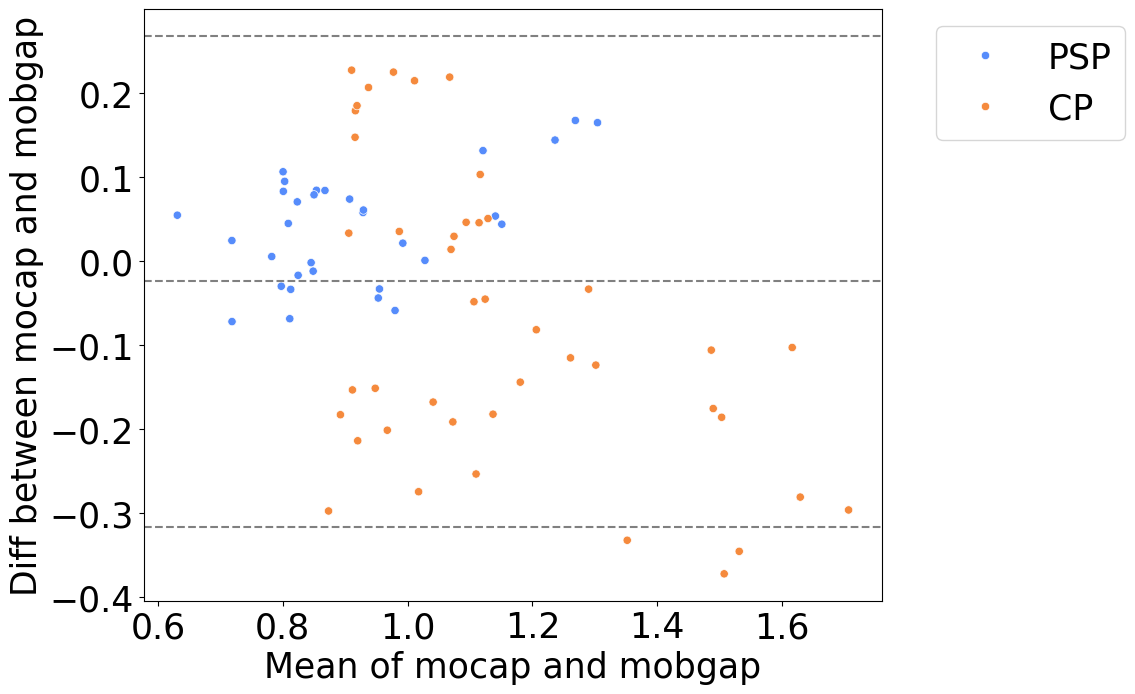

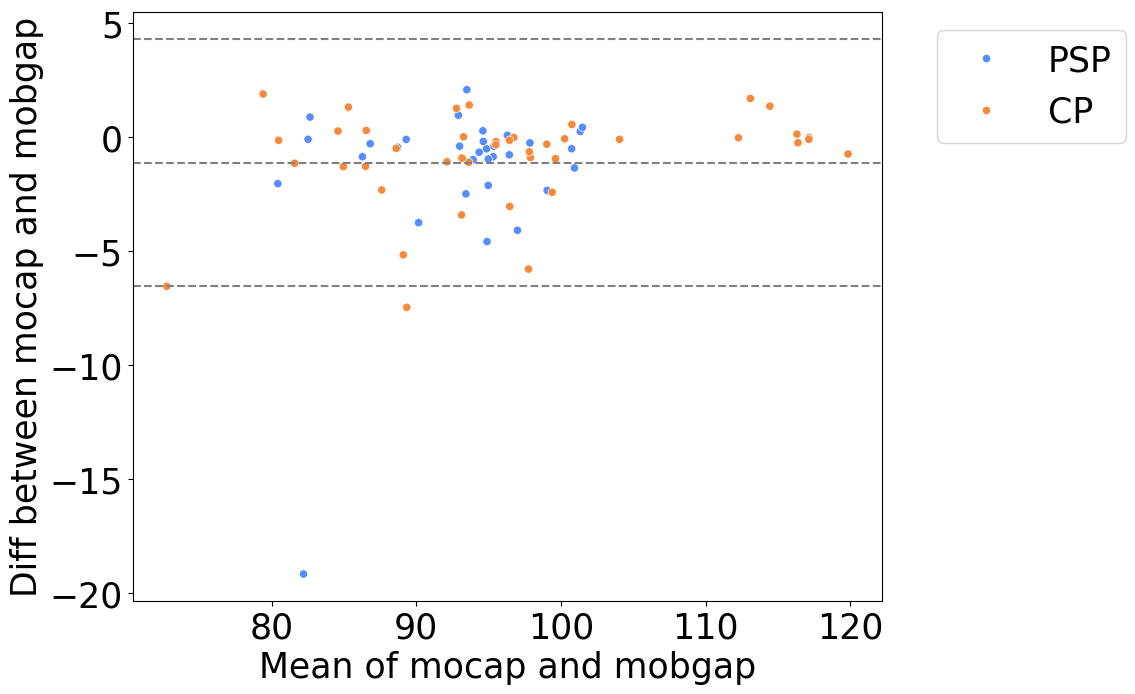

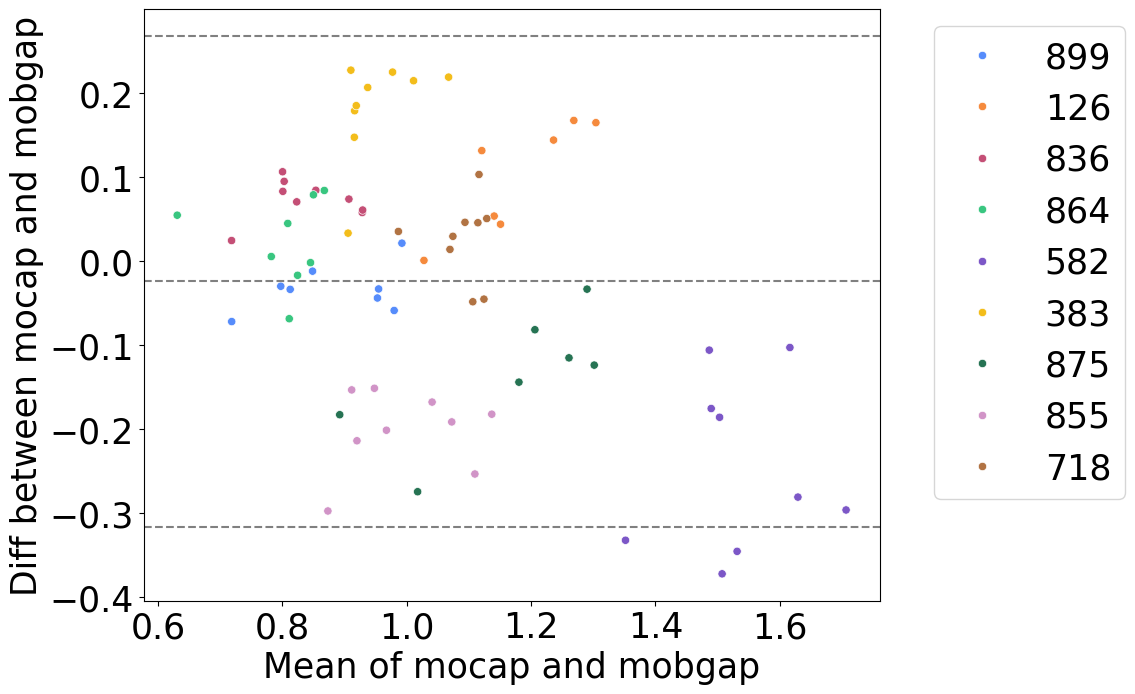

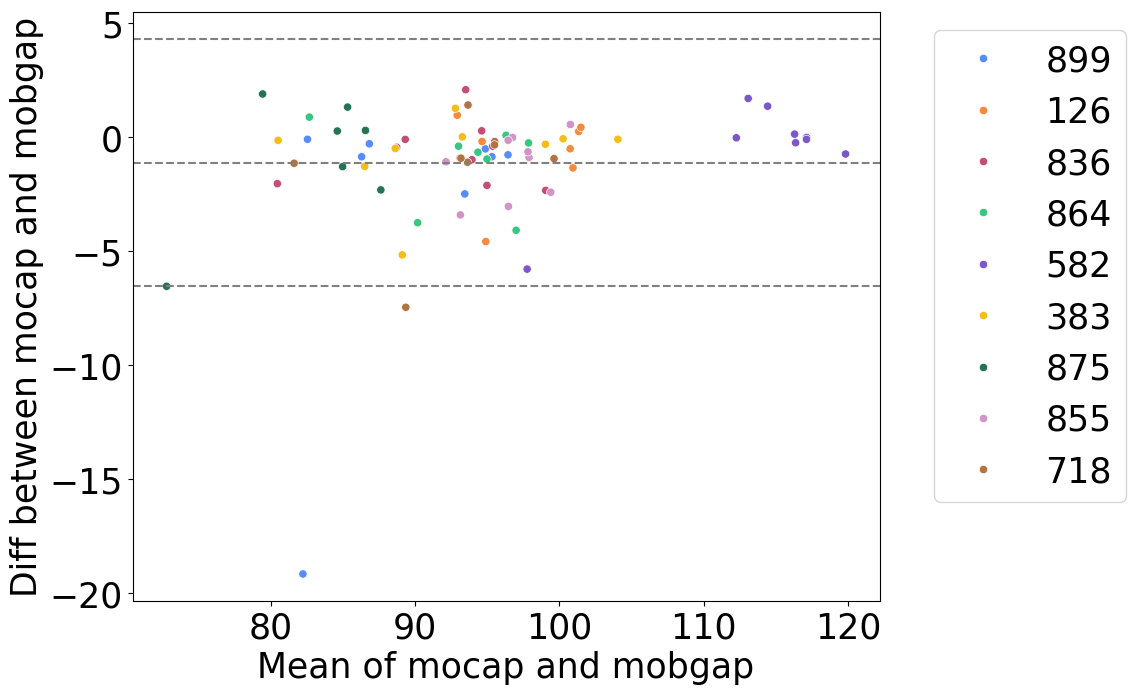


Mean IC Sensitivity = 0.9712936985252668
Mean IC Positive Predictive Value = 0.9260602195901229
Mean IC F1 Score = 0.9464596626727907


MAE stride length = 0.20615757086749295 [-0.06407454701850415, 0.4763896887534901]
MAE cadence = 1.3070382165713497 [-2.0154556694932446, 4.6295321026359435]
MAE walking speed = 0.18944293450377103 [-0.06464718589972968, 0.44353305490727174]


In [29]:
def bland_altman_plot(data1, data2, cohort, fig_scaler=12, *args, **kwargs):
    data1 = np.asarray(data1)
    data2 = np.asarray(data2)
    mean = np.mean([data1, data2], axis=0)
    diff = data1 - data2
    md   = np.mean(diff)
    sd   = np.std(diff, axis=0)
    plt.figure(figsize=(fig_scaler, fig_scaler*5/8))
    sns.scatterplot(x=mean, y=diff, hue=cohort, *args, **kwargs)
    plt.axhline(md,           color='gray', linestyle='--')
    plt.axhline(md + 1.96*sd, color='gray', linestyle='--')
    plt.axhline(md - 1.96*sd, color='gray', linestyle='--')
    plt.xlabel("Mean of mocap and mobgap")
    plt.ylabel("Diff between mocap and mobgap")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

def errors(mobgap_wb_dmo, mocap_wb_dmo):
    absolute_error = []
    relative_error = []
    for SS, RS in zip(mobgap_wb_dmo, mocap_wb_dmo):
        absolute_error.append(abs(SS-RS))
        relative_error = abs((SS-RS)/RS)*100
    mae = np.nanmean(absolute_error)
    upper_loa = mae + 1.96*np.nanstd(absolute_error)
    lower_loa = mae - 1.96*np.nanstd(absolute_error)
    return absolute_error, relative_error, mae, upper_loa, lower_loa

# wb-level stats stats
# calculate IC results into metrics dataframe
mask = all_metrics["IC_TPs"] > 0  # only keep rows where wb_ID is not NaN
all_metrics.loc[mask, "IC_Sensitivity"] = (
    all_metrics.loc[mask, "IC_TPs"] /
    (all_metrics.loc[mask, "IC_TPs"] + all_metrics.loc[mask, "IC_FNs"])
)
all_metrics.loc[mask, "IC_Positive_Predictive_Value"] = (
    all_metrics.loc[mask, "IC_TPs"] /
    (all_metrics.loc[mask, "IC_TPs"] + all_metrics.loc[mask, "IC_FPs"])
)
all_metrics.loc[mask, "IC_F1_Score"] = (
    (2*all_metrics.loc[mask, "IC_Sensitivity"]*all_metrics.loc[mask, "IC_Positive_Predictive_Value"]) /
    (all_metrics.loc[mask, "IC_Sensitivity"]+all_metrics.loc[mask, "IC_Positive_Predictive_Value"])
)

# subject-level stats
subject_metrics = pd.DataFrame(columns = ["Subject", "Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"])
for subject in subjects:
    cur_sub_metrics = all_metrics[all_metrics["subject"] == subject]
    subject_metrics_ser = pd.Series(index=["Subject", "Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"], dtype=object)
    subject_metrics_ser["Subject"] = subject
    subject_metrics_ser["Cohort"] = cur_sub_metrics["cohort"].iloc[0]
    subject_metrics_ser["Accuracy"] = (cur_sub_metrics["wb_TPs"].sum() + cur_sub_metrics["wb_TNs"].sum())/(cur_sub_metrics["wb_TPs"].sum() + cur_sub_metrics["wb_TNs"].sum() + cur_sub_metrics["wb_FPs"].sum() + cur_sub_metrics["wb_FNs"].sum())
    subject_metrics_ser["Sensitivity"] = (cur_sub_metrics["wb_TPs"].sum())/(cur_sub_metrics["wb_TPs"].sum() + cur_sub_metrics["wb_FNs"].sum())
    subject_metrics_ser["Positive Predictive Value"] = (cur_sub_metrics["wb_TPs"].sum())/(cur_sub_metrics["wb_TPs"].sum() + cur_sub_metrics["wb_FPs"].sum())
    subject_metrics_ser["Specificity"] = (cur_sub_metrics["wb_TNs"].sum())/(cur_sub_metrics["wb_TNs"].sum() + cur_sub_metrics["wb_FPs"].sum())
    subject_metrics_ser["F1 Score"] = (2*subject_metrics_ser["Positive Predictive Value"]*subject_metrics_ser["Sensitivity"])/(subject_metrics_ser["Positive Predictive Value"]+subject_metrics_ser["Sensitivity"])
    subject_metrics = pd.concat([subject_metrics, subject_metrics_ser.to_frame().T])


# cohort-level stats
cohort_metrics = pd.DataFrame(columns = ["Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"])
cohorts = all_metrics["cohort"].unique()
for cohort in cohorts:
    cur_cohort_metrics = all_metrics[all_metrics["cohort"] == cohort]
    cohort_metrics_ser = pd.Series(index = ["Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"], dtype=object)
    cohort_metrics_ser["Cohort"] = cohort
    cohort_metrics_ser["Accuracy"] = (cur_cohort_metrics["wb_TPs"].sum() + cur_cohort_metrics["wb_TNs"].sum())/(cur_cohort_metrics["wb_TPs"].sum() + cur_cohort_metrics["wb_TNs"].sum() + cur_cohort_metrics["wb_FPs"].sum() + cur_cohort_metrics["wb_FNs"].sum())
    cohort_metrics_ser["Sensitivity"] = (cur_cohort_metrics["wb_TPs"].sum())/(cur_cohort_metrics["wb_TPs"].sum() + cur_cohort_metrics["wb_FNs"].sum())
    cohort_metrics_ser["Positive Predictive Value"] = (cur_cohort_metrics["wb_TPs"].sum())/(cur_cohort_metrics["wb_TPs"].sum() + cur_cohort_metrics["wb_FPs"].sum())
    cohort_metrics_ser["Specificity"] = (cur_cohort_metrics["wb_TNs"].sum())/(cur_cohort_metrics["wb_TNs"].sum() + cur_cohort_metrics["wb_FPs"].sum())
    cohort_metrics_ser["F1 Score"] = (2*cohort_metrics_ser["Positive Predictive Value"]*cohort_metrics_ser["Sensitivity"])/(cohort_metrics_ser["Positive Predictive Value"]+cohort_metrics_ser["Sensitivity"])
    cohort_metrics = pd.concat([cohort_metrics, cohort_metrics_ser.to_frame().T])

# display all stats
display(all_metrics)
display(subject_metrics)
display(cohort_metrics)

all_metrics = all_metrics[all_metrics["cohort"] != "HA"] # drop HA
bland_altman_plot(all_metrics.loc[mask, "stride_length_mocap"], all_metrics.loc[mask, "stride_length_mobgap"], all_metrics.loc[mask, "cohort"])
bland_altman_plot(all_metrics.loc[mask, "cadence_mocap"], all_metrics.loc[mask, "cadence_mobgap"], all_metrics.loc[mask, "cohort"])
bland_altman_plot(all_metrics.loc[mask, "stride_length_mocap"], all_metrics.loc[mask, "stride_length_mobgap"], all_metrics.loc[mask, "subject"])
bland_altman_plot(all_metrics.loc[mask, "cadence_mocap"], all_metrics.loc[mask, "cadence_mobgap"], all_metrics.loc[mask, "subject"])

print()
print(f"Mean IC Sensitivity = {all_metrics["IC_Sensitivity"].mean()}")
print(f"Mean IC Positive Predictive Value = {all_metrics["IC_Positive_Predictive_Value"].mean()}")
print(f"Mean IC F1 Score = {all_metrics["IC_F1_Score"].mean()}")
print()

_, _, mae_stride_length, upper_loa_stride_length, lower_loa_stride_length = errors(all_metrics[all_metrics["cohort"] == "CP"]["stride_length_mobgap"], all_metrics[all_metrics["cohort"] == "CP"]["stride_length_mocap"])
_, _, mae_cadence, upper_loa_cadence, lower_loa_cadence = errors(all_metrics[all_metrics["cohort"] == "CP"]["cadence_mobgap"], all_metrics[all_metrics["cohort"] == "CP"]["cadence_mocap"])
_, _, mae_walking_speed, upper_loa_walking_speed, lower_loa_walking_speed = errors(all_metrics[all_metrics["cohort"] == "CP"]["walking_speed_mobgap"], all_metrics[all_metrics["cohort"] == "CP"]["walking_speed_mocap"])

print()
print(f"MAE stride length = {mae_stride_length} [{lower_loa_stride_length}, {upper_loa_stride_length}]")
print(f"MAE cadence = {mae_cadence} [{lower_loa_cadence}, {upper_loa_cadence}]")
print(f"MAE walking speed = {mae_walking_speed} [{lower_loa_walking_speed}, {upper_loa_walking_speed}]")
#print(f"{std_absolute_error=}")